# StreamSafe: exploratory data analysis

This notebook examines the source files, schemas, labels, harm categories, lengths, duplicate structure, and prefix annotations needed for a streaming-guardrail benchmark. It does not normalize or redistribute raw records.

## 1. Reproducibility and configuration

The dataset revision and random seed are read from the versioned configuration. Raw text is never displayed by this notebook.

In [1]:
from __future__ import annotations

import platform
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from streamguard_bench.data.inspect_schema import (
    align_streamsafe_prefixes,
    dataset_overview,
    distribution_for_role,
    duplicate_summary,
    length_statistics,
    missing_values_summary,
    prefix_transition_summary,
    schema_summary,
    streamsafe_trace_summary,
)
from streamguard_bench.data.load_streamsafe import load_streamsafe, load_yaml_config
from streamguard_bench.data.validate_raw import validate_tables

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'data_streamsafe.yaml'
config = load_yaml_config(CONFIG_PATH)
sns.set_theme(style='whitegrid')
print({
    'analysis_time_utc': datetime.now(UTC).isoformat(),
    'python': platform.python_version(),
    'repository': config['dataset']['repository'],
    'revision': config['dataset']['revision'],
    'random_seed': config['analysis']['random_seed'],
})

{'analysis_time_utc': '2026-08-24T16:12:58.012486+00:00', 'python': '3.12.13', 'repository': 'Solitude0630/StreamSafe', 'revision': '16d0ff1f42e980bb99bd36125583361b15c664e3', 'random_seed': 42}


In [2]:
bundle = load_streamsafe(
    repository=config['dataset']['repository'],
    revision=config['dataset']['revision'],
    cache_dir=PROJECT_ROOT / config['dataset']['cache_dir'],
    allow_remote_code=config['loading']['allow_remote_code'],
)
tables = bundle.tables
total_rows = sum(len(frame) for frame in tables.values())
print(f'Loaded {len(tables)} independent tables with {total_rows:,} total rows')
print(f'Loader mode: {bundle.loader_mode}')

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Loaded 5 independent tables with 61,811 total rows
Loader mode: snapshot_fallback: ValueError("Config name is missing.\nPlease pick one among the available configs: ['full_response', 'partial_response', 'test']\nExample of usage:\n\t`load_dataset('Solitude0630/StreamSafe', 'full_response')`")


## 2. Files and source schemas

In [3]:
tables_dir = PROJECT_ROOT / config['reports']['tables_dir']
figures_dir = PROJECT_ROOT / config['reports']['figures_dir']
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

overview = dataset_overview(tables)
schema = schema_summary(tables)
overview.to_csv(tables_dir / 'dataset_overview.csv', index=False)
schema.to_csv(tables_dir / 'raw_schema_summary.csv', index=False)
overview

,table,rows,columns,memory_mb,column_names
0,full_response_mix2_1_8k_train,6958,6,6.441,query | response | response_mode | risk_level ...
1,full_response_mix2_1_8k_val,772,6,0.714,query | response | response_mode | risk_level ...
2,partial_response_mix2_1_53k_train,49286,6,28.358,query | response | response_mode | risk_level ...
3,partial_response_mix2_1_53k_val,3595,6,2.076,query | response | response_mode | risk_level ...
4,test,1200,4,1.204,query | response | label | violated_categories


## 3. Data quality: missing values, duplicates, and structural warnings

In [4]:
missing = missing_values_summary(tables)
duplicates = duplicate_summary(tables)
validation = validate_tables(tables).to_frame()
missing.to_csv(tables_dir / 'missing_values.csv', index=False)
duplicates.to_csv(tables_dir / 'duplicate_summary.csv', index=False)
validation.to_csv(tables_dir / 'raw_validation.csv', index=False)
validation

,severity,table,code,count,details
0,warning,full_response_mix2_1_8k_train,duplicate_rows,36,Duplicates measured on detected text columns
1,info,full_response_mix2_1_8k_val,ok,772,No issues found
2,warning,partial_response_mix2_1_53k_train,duplicate_rows,158,Duplicates measured on detected text columns
3,warning,partial_response_mix2_1_53k_val,duplicate_rows,10,Duplicates measured on detected text columns
4,warning,test,duplicate_rows,2,Duplicates measured on detected text columns


## 4. Safety labels

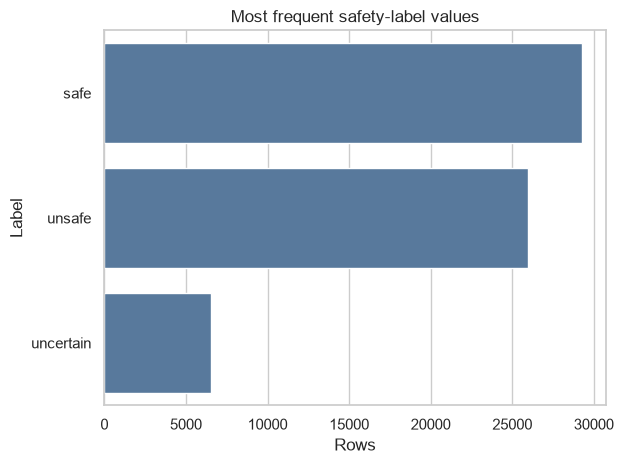

,table,column,value,count
3,full_response_mix2_1_8k_train,answer,safe,3903
4,full_response_mix2_1_8k_train,answer,unsafe,2965
5,full_response_mix2_1_8k_train,answer,uncertain,90
9,full_response_mix2_1_8k_val,answer,safe,424
10,full_response_mix2_1_8k_val,answer,unsafe,334
11,full_response_mix2_1_8k_val,answer,uncertain,14
15,partial_response_mix2_1_53k_train,answer,safe,22570
16,partial_response_mix2_1_53k_train,answer,unsafe,20620
17,partial_response_mix2_1_53k_train,answer,uncertain,6096
21,partial_response_mix2_1_53k_val,answer,safe,1705


In [5]:
all_label_fields = distribution_for_role(tables, 'label')
labels = all_label_fields[all_label_fields['column'].isin(['answer', 'label'])].copy()
labels.to_csv(tables_dir / 'label_distribution.csv', index=False)
if not labels.empty:
    plot_data = labels.groupby('value', as_index=False)['count'].sum().nlargest(20, 'count')
    ax = sns.barplot(data=plot_data, x='count', y='value', color='#4C78A8')
    ax.set(title='Most frequent safety-label values', xlabel='Rows', ylabel='Label')
    plt.tight_layout()
    plt.savefig(figures_dir / 'label_distribution.png', dpi=160, bbox_inches='tight')
    plt.show()
labels.head(30)

## 5. Harm categories

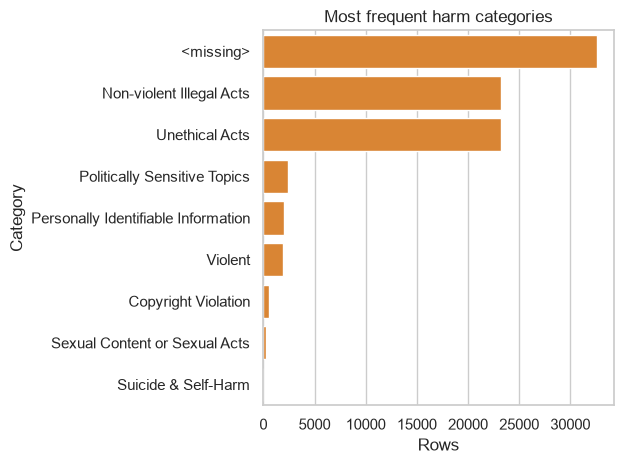

,table,column,value,count
0,full_response_mix2_1_8k_train,violated_categories,<missing>,3902
1,full_response_mix2_1_8k_train,violated_categories,Unethical Acts,2654
2,full_response_mix2_1_8k_train,violated_categories,Non-violent Illegal Acts,2580
3,full_response_mix2_1_8k_train,violated_categories,Politically Sensitive Topics,262
4,full_response_mix2_1_8k_train,violated_categories,Personally Identifiable Information,256
5,full_response_mix2_1_8k_train,violated_categories,Violent,216
6,full_response_mix2_1_8k_train,violated_categories,Copyright Violation,62
7,full_response_mix2_1_8k_train,violated_categories,Sexual Content or Sexual Acts,28
8,full_response_mix2_1_8k_train,violated_categories,Suicide & Self-Harm,1
9,full_response_mix2_1_8k_val,violated_categories,<missing>,425


In [6]:
categories = distribution_for_role(tables, 'category')
categories.to_csv(tables_dir / 'harm_category_distribution.csv', index=False)
if not categories.empty:
    plot_data = categories.groupby('value', as_index=False)['count'].sum().nlargest(20, 'count')
    ax = sns.barplot(data=plot_data, x='count', y='value', color='#F58518')
    ax.set(title='Most frequent harm categories', xlabel='Rows', ylabel='Category')
    plt.tight_layout()
    plt.savefig(figures_dir / 'harm_category_distribution.png', dpi=160, bbox_inches='tight')
    plt.show()
categories.head(30)

## 6. Prompt and response lengths

Character, UTF-8 byte, word, and approximate sentence lengths are computed without persisting source text. Token lengths will be added after the Qwen3Guard tokenizer is introduced.

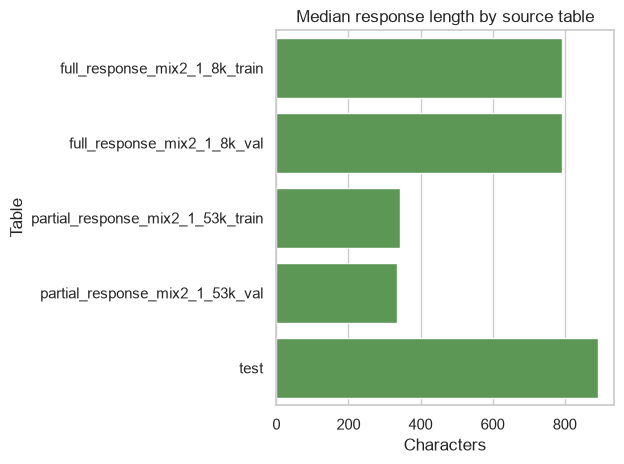

,table,column,role,measure,count,mean,std,min,p25,median,p75,p95,max
0,full_response_mix2_1_8k_train,query,prompt,characters,6958,79.657,43.408,2,59.00,70.0,83.00,173.00,498
1,full_response_mix2_1_8k_train,query,prompt,bytes_utf8,6958,79.747,43.390,2,59.00,70.0,83.00,173.00,498
2,full_response_mix2_1_8k_train,query,prompt,words,6958,14.206,7.456,1,11.00,12.0,15.00,30.00,83
3,full_response_mix2_1_8k_train,query,prompt,sentences_approx,6958,1.122,0.392,1,1.00,1.0,1.00,2.00,6
4,full_response_mix2_1_8k_train,response,response,characters,6958,756.849,286.394,4,585.00,792.0,936.75,1144.30,6337
5,full_response_mix2_1_8k_train,response,response,bytes_utf8,6958,757.749,286.328,4,587.00,793.0,937.00,1144.30,6339
6,full_response_mix2_1_8k_train,response,response,words,6958,119.558,42.113,1,95.00,125.0,146.00,177.00,758
7,full_response_mix2_1_8k_train,response,response,sentences_approx,6958,6.949,3.038,1,5.00,7.0,8.00,11.00,34
8,full_response_mix2_1_8k_val,query,prompt,characters,772,82.307,52.250,7,58.00,69.0,82.00,184.00,494
9,full_response_mix2_1_8k_val,query,prompt,bytes_utf8,772,82.372,52.234,7,59.00,69.0,82.00,184.00,494


In [7]:
lengths = length_statistics(tables)
lengths.to_csv(tables_dir / 'length_statistics.csv', index=False)
response_lengths = lengths[(lengths['role'] == 'response') & (lengths['measure'] == 'characters')]
if not response_lengths.empty:
    ax = sns.barplot(data=response_lengths, x='median', y='table', color='#54A24B')
    ax.set(title='Median response length by source table', xlabel='Characters', ylabel='Table')
    plt.tight_layout()
    plt.savefig(figures_dir / 'response_length_by_table.png', dpi=160, bbox_inches='tight')
    plt.show()
lengths

## 7. Prefix structure and label transitions

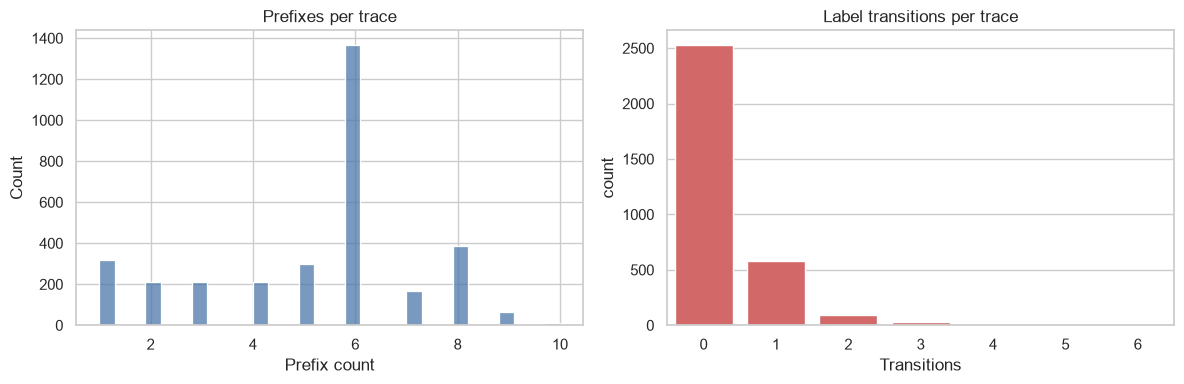

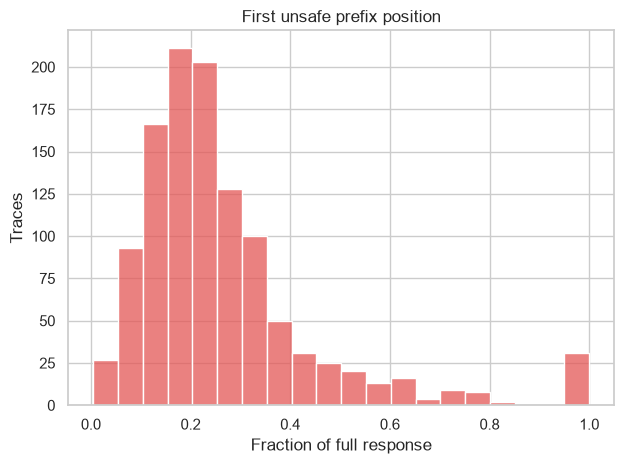

,split,status,size,percent
0,train,ambiguous,724,1.468977
1,train,unique,15280,31.002719
2,train,unmatched,33282,67.528304
3,val,ambiguous,12,0.333797
4,val,unique,1588,44.172462
5,val,unmatched,1995,55.493741


In [8]:
generic_transitions = prefix_transition_summary(tables)
alignment_parts = []
trace_parts = []
for split in ('train', 'val'):
    full_name = next(name for name in tables if name.startswith('full_response') and name.endswith(split))
    partial_name = next(name for name in tables if name.startswith('partial_response') and name.endswith(split))
    aligned = align_streamsafe_prefixes(tables[full_name], tables[partial_name])
    aligned['split'] = split
    traces = streamsafe_trace_summary(aligned)
    traces['split'] = split
    alignment_parts.append(aligned)
    trace_parts.append(traces)
alignment = pd.concat(alignment_parts, ignore_index=True)
transitions = pd.concat(trace_parts, ignore_index=True)
alignment_quality = alignment.groupby(['split', 'status'], as_index=False).size()
alignment_quality['percent'] = alignment_quality.groupby('split')['size'].transform(lambda s: 100 * s / s.sum())
alignment_quality.to_csv(tables_dir / 'prefix_alignment_quality.csv', index=False)
transitions.to_csv(tables_dir / 'prefix_transition_summary.csv', index=False)
if not transitions.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(transitions['prefix_count'], bins=30, ax=axes[0], color='#4C78A8')
    axes[0].set(title='Prefixes per trace', xlabel='Prefix count')
    sns.countplot(data=transitions, x='label_transitions', ax=axes[1], color='#E45756')
    axes[1].set(title='Label transitions per trace', xlabel='Transitions')
    plt.tight_layout()
    plt.savefig(figures_dir / 'prefix_structure.png', dpi=160, bbox_inches='tight')
    plt.show()
    unsafe_onsets = transitions['first_unsafe_fraction'].dropna()
    if not unsafe_onsets.empty:
        ax = sns.histplot(unsafe_onsets, bins=20, color='#E45756')
        ax.set(title='First unsafe prefix position', xlabel='Fraction of full response', ylabel='Traces')
        plt.tight_layout()
        plt.savefig(figures_dir / 'first_unsafe_prefix_position.png', dpi=160, bbox_inches='tight')
        plt.show()
alignment_quality

## 8. Split overlap and candidate subset

The duplicate report provides within-table evidence. Exact cross-split overlap and a balanced 500-trace subset require the next normalization stage, because source files may use different identifiers and schemas.

In [9]:
safety_counts = labels.groupby('value')['count'].sum().to_dict()
unique_alignment_rate = 100 * (alignment['status'] == 'unique').mean()
candidate_summary = pd.DataFrame({
    'question': [
        'Are safe and unsafe labels discoverable?',
        'Are harm categories discoverable?',
        'Can prefix traces be grouped with current identifiers?',
        'Is a balanced 500-trace subset immediately feasible?',
    ],
    'answer_from_raw_inspection': [
        {'safe': int(safety_counts.get('safe', 0)), 'unsafe': int(safety_counts.get('unsafe', 0)), 'uncertain': int(safety_counts.get('uncertain', 0))},
        not categories.empty,
        {'uniquely_aligned_traces': len(transitions), 'unique_prefix_rate_percent': round(float(unique_alignment_rate), 2)},
        len(transitions) >= 500 and safety_counts.get('safe', 0) >= 250 and safety_counts.get('unsafe', 0) >= 250,
    ],
})
candidate_summary.to_csv(tables_dir / 'candidate_subset_assessment.csv', index=False)
candidate_summary

,question,answer_from_raw_inspection
0,Are safe and unsafe labels discoverable?,"{'safe': 29285, 'unsafe': 25982, 'uncertain': ..."
1,Are harm categories discoverable?,True
2,Can prefix traces be grouped with current iden...,"{'uniquely_aligned_traces': 3249, 'unique_pref..."
3,Is a balanced 500-trace subset immediately fea...,True


## 9. Limitations and next steps

1. Source schemas are intentionally kept separate.
2. Column-role detection is heuristic and must be confirmed against the dataset documentation.
3. Exact unsafe-onset positions require normalized full-response and prefix alignment.
4. Token lengths depend on the guard model tokenizer and are deferred to model integration.
5. The next stage must normalize records, define boundary semantics, construct the first balanced subset, and manually audit annotations.

In [10]:
total_rows = int(overview['rows'].sum())
full_rows = int(overview[overview['table'].str.startswith('full_response')]['rows'].sum())
partial_rows = int(overview[overview['table'].str.startswith('partial_response')]['rows'].sum())
test_rows = int(overview[overview['table'] == 'test']['rows'].sum())
duplicate_rows = int(
    validation.loc[validation['code'] == 'duplicate_rows', 'count'].sum()
)
unsafe_traces = transitions['first_unsafe_fraction'].notna().sum()
late_unsafe = int((transitions['first_unsafe_fraction'] >= 0.75).sum())
summary = f'''# StreamSafe exploratory analysis

## Dataset version

- Repository: `{bundle.repository}`
- Immutable revision: `{bundle.resolved_revision}`
- License declared by the source: CC BY 4.0

## Files and schemas

The snapshot contains {len(overview)} data tables and {total_rows:,} rows: {full_rows:,} full-response rows, {partial_rows:,} partial-response rows, and {test_rows:,} held-out test rows. Full and partial training tables share six fields; the held-out test table has a separate four-field binary-label schema. See `reports/tables/dataset_overview.csv` and `raw_schema_summary.csv`.

## Labels and harm categories

The source exposes three-way `answer` labels for training and validation and binary `label` values for test. Aggregate counts are {safety_counts}. Harm categories are multi-label; their distribution is recorded in `harm_category_distribution.csv`.

## Length and prefix structure

A total of {len(transitions):,} response traces could be reconstructed from uniquely matched prefixes. The unique-prefix alignment rate is {unique_alignment_rate:.2f}%. Among reconstructed traces, {unsafe_traces:,} contain an observed unsafe prefix and {late_unsafe:,} first become unsafe after at least 75% of the full response length. See `prefix_alignment_quality.csv` and `prefix_transition_summary.csv`.

## Data-quality findings

The raw validation found {duplicate_rows:,} rows participating in exact duplicate prompt-response groups across source tables. Cross-split leakage requires normalization. Prefixes without a unique full-response match are retained as unmatched or ambiguous rather than assigned heuristically.

## Recommendation for the first benchmark subset

A 500-trace baseline subset is feasible from the available label counts. Sampling should operate on normalized trace identifiers, stratify by final safety label and harm category, and explicitly include early-, middle-, and late-onset unsafe traces.

## Next decisions

- Normalize full and prefix records into a model-independent trace schema.
- Define whether unsafe onset is the first unsafe sentence boundary or the first unsafe character span.
- Build and manually audit the first balanced subset.
- Keep unmatched and ambiguous prefix groups out of leakage metrics until reviewed.
'''
summary_path = PROJECT_ROOT / config['reports']['summary_path']
summary_path.write_text(summary, encoding='utf-8')
print(f'Wrote {summary_path}')

Wrote /Users/admin/Desktop/SelfImprove/Science/Streaming Guardrails/reports/eda_summary.md
